### Album prediction


In [1]:
import os
from dotenv import load_dotenv
from pathlib import Path
import pandas as pd
import psycopg
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import pickle

In [2]:

# Load .env from parent directory
load_dotenv(dotenv_path=Path("../.env"))

# Connect
conn = psycopg.connect(
    dbname=os.getenv("DATABASE"),
    user=os.getenv("DB_USERNAME"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("POSTGRES"),
    port=5432
)

print(f"Connection successful")

query = """
        SELECT DISTINCT release_group.id AS id, release_group.artist_credit AS artist_credit, release_group.type AS type, secondary_type AS sec_type, status, language ,
                        script, release_group_tag.tag, release_group_tag.count, genre.id AS genre_id, release_group_meta.first_release_date_year AS year
        FROM release_group
        LEFT JOIN release_group_secondary_type_join ON release_group.id = release_group_secondary_type_join.release_group
        LEFT JOIN release ON release.release_group = release_group.id
        LEFT JOIN release_group_tag ON release_group_tag.release_group = release_group.id
        LEFT JOIN tag ON release_group_tag.tag = tag.id
        LEFT JOIN genre ON genre.name = tag.name
        LEFT JOIN release_group_meta ON release_group_meta.id = release_group.id
        """
data_sql = pd.read_sql_query(query, conn)
conn.close()

Connection successful


/tmp/ipykernel_69920/602793385.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_sql = pd.read_sql_query(query, conn)


In [3]:
data_pre_group = data_sql.copy()

### Exploratory Data Analysis

In [4]:
data_pre_group.dtypes

id                 int64
artist_credit      int64
type             float64
sec_type         float64
status           float64
language         float64
script           float64
tag              float64
count            float64
genre_id         float64
year             float64
dtype: object

In [5]:
data_pre_group.dtypes.value_counts()

float64    9
int64      2
Name: count, dtype: int64

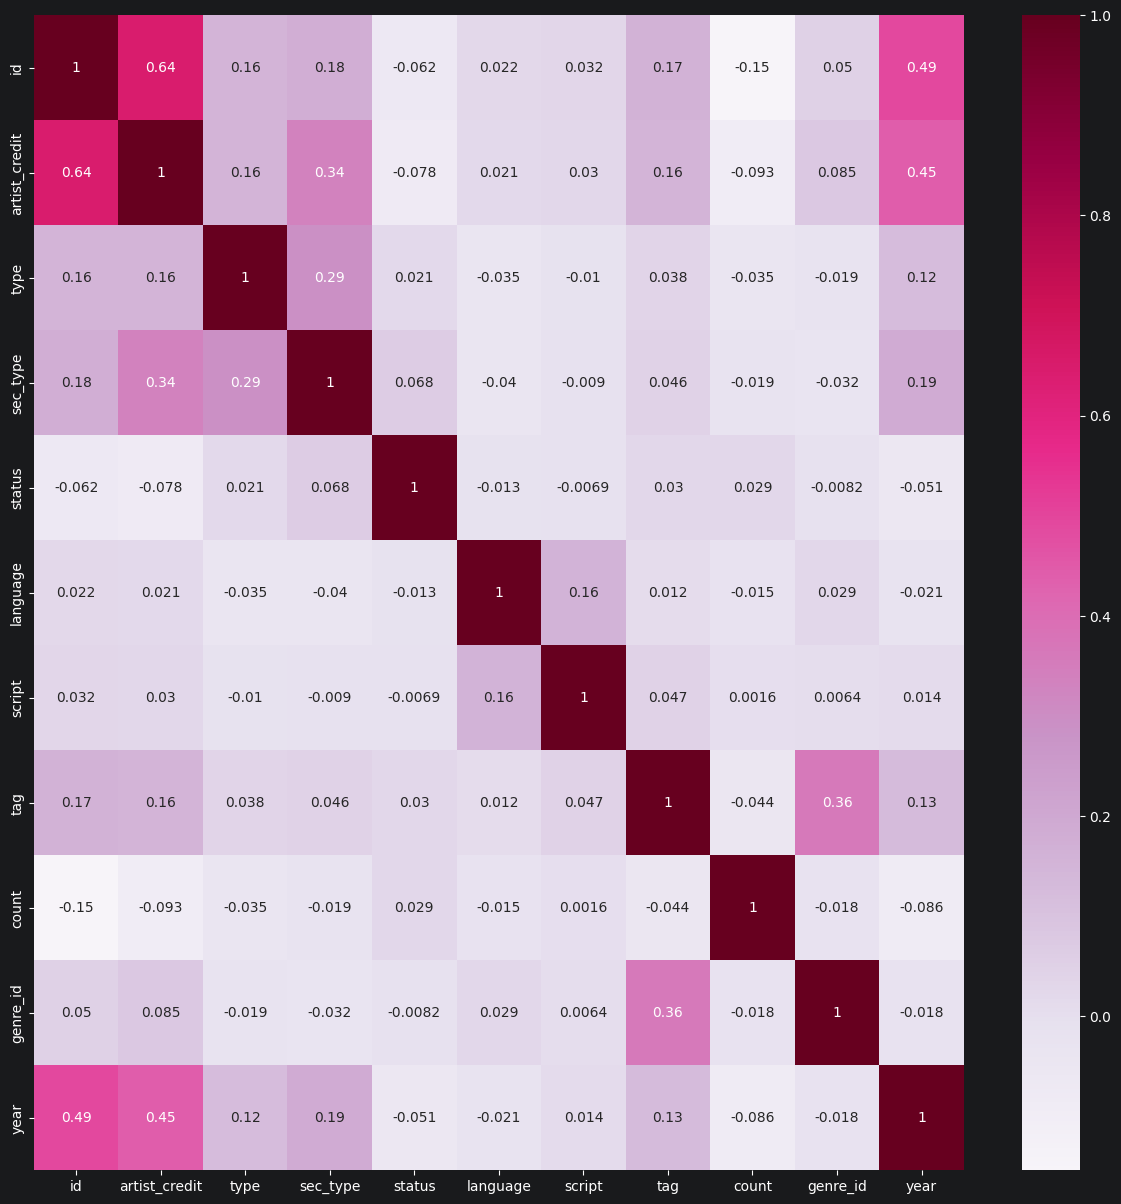

In [6]:
plt.figure(figsize = (15,15))
sns.heatmap(data_pre_group.corr(numeric_only = True),
annot=True,
cmap="PuRd");

In [7]:
number_of_duplicated_rows = data_pre_group.duplicated().sum()
number_of_duplicated_rows, data_pre_group.shape

(np.int64(0), (8431338, 11))

In [8]:
data_pre_group = data_pre_group.drop_duplicates()
data_pre_group.shape

(8431338, 11)

### Set genre and tag as NaN if count is not positive

In [9]:
nan_count_pres = data_pre_group['tag'].isna().sum()
cols_to_update = ['genre_id', 'tag']
data_pre_group[cols_to_update] = data_pre_group[cols_to_update].where(data_pre_group['count'] > 0)
nan_count_post = data_pre_group['tag'].isna().sum()
print(f"Removed {nan_count_post - nan_count_pres} downvoted genre")

Removed 97124 downvoted genre


,id,artist_credit,type,sec_type,status,language,script,tag,count,genre_id,year
0,2,1,1.0,1.0,1.0,120.0,28.0,1186.0,2.0,NaN,2000.0
1,2,1,1.0,1.0,1.0,120.0,28.0,92310.0,1.0,NaN,2000.0
2,4,4,1.0,NaN,1.0,120.0,28.0,1.0,2.0,NaN,1991.0
3,4,4,1.0,NaN,1.0,120.0,28.0,11.0,10.0,132.0,1991.0
4,4,4,1.0,NaN,1.0,120.0,28.0,12.0,9.0,115.0,1991.0
...,...,...,...,...,...,...,...,...,...,...,...
8431333,4821678,2806995,2.0,NaN,1.0,120.0,28.0,284.0,1.0,209.0,2026.0
8431334,4821678,2806995,2.0,NaN,1.0,120.0,28.0,1012.0,1.0,208.0,2026.0
8431335,4821678,2806995,2.0,NaN,1.0,120.0,28.0,1211.0,1.0,12.0,2026.0
8431336,4821679,4958268,1.0,NaN,1.0,120.0,NaN,NaN,NaN,NaN,2015.0


### Drop rows where genre_id is null

In [11]:
data_pre_group = data_pre_group.dropna(subset=["genre_id"])
data_pre_group

,id,artist_credit,type,sec_type,status,language,script,tag,count,genre_id,year
3,4,4,1.0,NaN,1.0,120.0,28.0,11.0,10.0,132.0,1991.0
4,4,4,1.0,NaN,1.0,120.0,28.0,12.0,9.0,115.0,1991.0
5,4,4,1.0,NaN,1.0,120.0,28.0,20.0,2.0,14.0,1991.0
7,4,4,1.0,NaN,1.0,120.0,28.0,76.0,1.0,95.0,1991.0
8,4,4,1.0,NaN,1.0,120.0,28.0,77.0,1.0,203.0,1991.0
...,...,...,...,...,...,...,...,...,...,...,...
8431058,4821415,4951286,2.0,NaN,1.0,120.0,28.0,80.0,1.0,213.0,2021.0
8431059,4821415,4951286,2.0,NaN,1.0,120.0,28.0,149.0,1.0,182.0,2021.0
8431333,4821678,2806995,2.0,NaN,1.0,120.0,28.0,284.0,1.0,209.0,2026.0
8431334,4821678,2806995,2.0,NaN,1.0,120.0,28.0,1012.0,1.0,208.0,2026.0


### Merge into release_group

In [12]:
def most_common(series):
    """Return the most common non-null value in the series"""
    cleaned = series.dropna()
    if len(cleaned) == 0:
        return None
    return Counter(cleaned).most_common(1)[0][0]

grouped = data_pre_group.groupby('id').apply(
    lambda g: pd.Series({
        'genre_id': g.loc[g['count'].idxmax(), 'genre_id'] if g['count'].dropna().any() else None,
        'status': most_common(g['status']),
        'language': most_common(g['language']),
        'script': most_common(g['script']),
    })
).reset_index()

,id,genre_id,status,language,script
0,4,403.0,1.0,120.0,28.0
1,11,222.0,1.0,120.0,28.0
2,12,346.0,1.0,120.0,28.0
3,13,222.0,1.0,120.0,28.0
4,28,132.0,1.0,120.0,28.0
...,...,...,...,...,...
1621918,4821204,804.0,NaN,NaN,NaN
1621919,4821207,213.0,1.0,120.0,28.0
1621920,4821335,115.0,1.0,120.0,28.0
1621921,4821415,213.0,1.0,120.0,28.0


In [13]:
sec_type_data = data_pre_group.groupby('id')['sec_type'].first().reset_index()
type_data = data_pre_group.groupby('id')['type'].first().reset_index()
year_data = data_pre_group.groupby('id')['year'].first().reset_index()
# genre_data = data_pre_group.groupby('id')['genre_id'].first().reset_index()

merged = grouped.merge(sec_type_data, on='id', how="left")
merged = merged.merge(type_data, on='id', how="left")
merged = merged.merge(year_data, on='id', how="left")
# merged = merged.merge(genre_data, on='id', how="left")

### Setting null sec_type to 0

In [16]:
data = merged.copy()

data['sec_type'] = data['sec_type'].fillna(0)
data

,id,genre_id,status,language,script,sec_type,type,year
0,4,403.0,1.0,120.0,28.0,0.0,1.0,1991.0
1,11,222.0,1.0,120.0,28.0,0.0,1.0,1996.0
2,12,346.0,1.0,120.0,28.0,0.0,1.0,2000.0
3,13,222.0,1.0,120.0,28.0,0.0,1.0,1995.0
4,28,132.0,1.0,120.0,28.0,0.0,1.0,1999.0
...,...,...,...,...,...,...,...,...
1621918,4821204,804.0,NaN,NaN,NaN,1.0,11.0,NaN
1621919,4821207,213.0,1.0,120.0,28.0,0.0,2.0,2021.0
1621920,4821335,115.0,1.0,120.0,28.0,0.0,2.0,2016.0
1621921,4821415,213.0,1.0,120.0,28.0,0.0,2.0,2021.0


### train Pipeline

In [18]:
def train_knn_from_data(data, n_neighbors=10, model_prefix="mb_knn_baseline", save_dir="../pickles"):
    """
    Train a KNN baseline model using a sklearn Pipeline and save to ONE .pkl file.
    Baseline: genre_id and tag are treated as single values (not lists).
    After grouping: drop rows where genre_id is null.
    """

    data_model = data.copy()

    # For baseline: take single value for genre_id and tag (use first element if list)
    def get_single_value(x):
        if isinstance(x, list):
            return x[0] if len(x) > 0 else None
        return x

    data_model["genre_id"] = data_model["genre_id"].apply(get_single_value)
    # data_model["tag"] = data_model["tag"].apply(get_single_value)

    # Feature columns: everything except id and artist_credit
    exclude_cols = ["id", "artist_credit", "tag", "count"]
    feature_cols = [c for c in data_model.columns if c not in exclude_cols]

    # Create actual sklearn Pipeline
    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("knn", NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute"))
    ])

    # Fit pipeline
    X = data_model[feature_cols]
    pipeline.fit(X)

    # id -> row index mapping
    id_to_idx = {row_id: idx for idx, row_id in enumerate(data_model["id"])}

    # Create save directory if it doesn't exist
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # Save everything to ONE pickle file
    bundle = {
        "pipeline": pipeline,
        "data_model": data_model,
        "feature_cols": feature_cols,
        "id_to_idx": id_to_idx,
        "n_neighbors": n_neighbors,
    }

    pkl_path = save_path / f"{model_prefix}.pkl"
    with open(pkl_path, "wb") as f:
        pickle.dump(bundle, f)

    print(f"Rows after dropping null genre_id: {len(data_model)}")
    print(f"Features used: {feature_cols}")
    print(f"Model saved to: {pkl_path}")

    return bundle

In [19]:
# ----------------------------
# 2. LOAD SAVED OBJECTS (FROM SINGLE PKL FILE)
# ----------------------------

def load_knn_bundle(model_prefix="mb_knn_baseline", save_dir="../pickles"):
    save_path = Path(save_dir)

    pkl_path = save_path / f"{model_prefix}.pkl"

    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)

    return bundle

# ----------------------------
# 3. QUERY 1 ID
# ----------------------------

def find_similar_by_id(target_id, bundle, n_neighbors=None, exclude_self=False):
    pipeline = bundle["pipeline"]
    data_model = bundle["data_model"]
    feature_cols = bundle["feature_cols"]
    id_to_idx = bundle["id_to_idx"]

    if n_neighbors is None:
        n_neighbors = bundle.get("n_neighbors", 10)

    if target_id not in id_to_idx:
        raise ValueError(f"ID {target_id} not found in dataset")

    row_idx = id_to_idx[target_id]
    row_data = data_model.iloc[row_idx:row_idx+1]  # Keep as DataFrame

    # Access the imputer step directly: pipeline.named_steps['imputer']
    imputer = pipeline.named_steps['imputer']
    knn = pipeline.named_steps['knn']

    # Transform only through imputer, then query KNN
    X_row = imputer.transform(row_data[feature_cols])
    distances, indices = knn.kneighbors(X_row, n_neighbors=n_neighbors)

    neighbors = data_model.iloc[indices[0]].copy()
    neighbors["distance"] = distances[0]
    neighbors["query_id"] = target_id

    if exclude_self:
        neighbors = neighbors[neighbors["id"] != target_id].reset_index(drop=True)

    return neighbors


# ----------------------------
# 4. QUERY A LIST OF IDS (RANDOMIZED ORDER)
# ----------------------------

def find_similar_by_ids_flat(target_ids, bundle, n_neighbors=None, exclude_self=False, seed=None):
    pipeline = bundle["pipeline"]
    data_model = bundle["data_model"]
    feature_cols = bundle["feature_cols"]
    id_to_idx = bundle["id_to_idx"]

    if n_neighbors is None:
        n_neighbors = bundle.get("n_neighbors", 10)

    if seed is not None:
        random.seed(seed)

    # Access the imputer and knn steps once
    imputer = pipeline.named_steps['imputer']
    knn = pipeline.named_steps['knn']

    all_results = []

    for target_id in target_ids:
        if target_id not in id_to_idx:
            print(f"Warning: ID {target_id} not found, skipping.")
            continue

        row_idx = id_to_idx[target_id]
        row_data = data_model.iloc[row_idx:row_idx+1]  # Keep as DataFrame

        # Transform only through imputer, then query KNN
        X_row = imputer.transform(row_data[feature_cols])
        distances, indices = knn.kneighbors(X_row, n_neighbors=n_neighbors)

        neighbors = data_model.iloc[indices[0]].copy()
        neighbors["distance"] = distances[0]
        neighbors["query_id"] = target_id

        if exclude_self:
            neighbors = neighbors[neighbors["id"] != target_id]

        all_results.append(neighbors)

    if not all_results:
        return pd.DataFrame()

    result = pd.concat(all_results, ignore_index=True)

    # Randomize the order of the return list
    result = result.sample(frac=1, random_state=seed).reset_index(drop=True)

    return result

# ----------------------------
# 5. OPTIONAL CLEANUP FOR type_x / type_y
# ----------------------------

def clean_type_columns(df):
    df = df.copy()

    if "type_x" in df.columns and "type_y" in df.columns:
        df["type"] = df["type_x"]
        df = df.drop(columns=["type_x", "type_y"])
    elif "type_x" in df.columns:
        df = df.rename(columns={"type_x": "type"})
    elif "type_y" in df.columns:
        df = df.rename(columns={"type_y": "type"})

    return df

In [20]:
#TODO: structure model prefix

bundle = train_knn_from_data(
    data=data,
    n_neighbors=10,
    model_prefix="mb_knn_baseline",
    save_dir="../pickles"
)

pipeline = bundle["pipeline"]

Rows after dropping null genre_id: 1621923
Features used: ['genre_id', 'status', 'language', 'script', 'sec_type', 'type', 'year']
Model saved to: ../pickles/mb_knn_baseline.pkl


In [21]:
# Single id
similar_one = find_similar_by_id(
    target_id=12345,
    bundle=bundle,
    n_neighbors=10,
    exclude_self=True
)

similar_one = clean_type_columns(similar_one)

columns_to_show = [
    c for c in [
        "query_id", "id", "type", "year", "genre_id", "tag",
        "sec_type", "status", "language", "script", "distance"
    ] if c in similar_one.columns
]
similar_one[columns_to_show].head(10)

,query_id,id,type,year,genre_id,sec_type,status,language,script,distance
0,12345,2224853,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
1,12345,442331,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
2,12345,442345,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
3,12345,326820,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
4,12345,813493,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
5,12345,3294168,1.0,1993.0,132.0,0.0,1.0,NaN,NaN,2.220446e-16
6,12345,455580,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
7,12345,142318,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
8,12345,8248,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
9,12345,930009,NaN,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16


In [23]:
all_similar = find_similar_by_ids_flat(
    target_ids=[12345, 67890, 5435],
    bundle=bundle,
    n_neighbors=10,
    exclude_self=True,
    seed=None
)

all_similar = clean_type_columns(all_similar)

columns_to_show = [
    c for c in [
        "query_id", "id", "type", "year", "genre_id", "tag",
        "sec_type", "status", "language", "script", "distance"
    ] if c in all_similar.columns
]
all_similar[columns_to_show].head(30)

,query_id,id,type,year,genre_id,sec_type,status,language,script,distance
0,12345,930009,NaN,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
1,67890,1175653,1.0,1957.0,222.0,0.0,1.0,120.0,28.0,0.000000e+00
2,12345,3294168,1.0,1993.0,132.0,0.0,1.0,NaN,NaN,2.220446e-16
3,67890,1260515,1.0,1957.0,222.0,0.0,1.0,120.0,28.0,0.000000e+00
4,12345,813493,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
5,67890,78668,1.0,1957.0,222.0,0.0,1.0,120.0,28.0,0.000000e+00
6,67890,2603509,1.0,1957.0,222.0,0.0,1.0,NaN,NaN,0.000000e+00
7,67890,1485558,1.0,1957.0,222.0,0.0,NaN,NaN,NaN,0.000000e+00
8,12345,326820,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
9,12345,8248,1.0,1993.0,132.0,0.0,1.0,120.0,28.0,2.220446e-16
